In [1]:
# Bibliotecas utilizadas

import pandas as pd

# Leitura dos dados

df = pd.read_csv('/content/manutencao_preditiva.csv')

In [2]:
# Leitura dos dados

df = pd.read_csv('/content/manutencao_preditiva.csv')

# Transformação das informações do tipo de falha

map_falha = {
    "No Failure": 0,
    "Heat Dissipation Failure": 1,
    "Power Failure": 2,
    "Overstrain Failure": 3,
    "Tool Wear Failure": 4,
    "Random Failures": 5
}

# Criando nova coluna com valores numéricos
df["Tipo da Falha Num"] = df["Tipo da Falha"].map(map_falha)

# Transformação das informações da coluna Tipo

map_falha = {
    "H": 0,
    "L": 1,
    "M": 2,
}

# Criando nova coluna com valores numéricos
df["Tipo Num"] = df["Tipo"].map(map_falha)
df

,UDI,ID Produto,Tipo,Temperatura Ar [K],Temperatura Processo [K],Velocidade Rotacao [rpm],Torque [Nm],Desgaste Ferramenta [min],Alvo,Tipo da Falha,Tipo da Falha Num,Tipo Num
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure,0,2
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure,0,1
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure,0,1
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure,0,1
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure,0,2
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure,0,2
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure,0,0


In [11]:
df['Tipo da Falha'].value_counts()

,count
Tipo da Falha,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


In [12]:
df[df['Tipo da Falha'] == 'Tool Wear Failure']

,UDI,ID Produto,Tipo,Temperatura Ar [K],Temperatura Processo [K],Velocidade Rotacao [rpm],Torque [Nm],Desgaste Ferramenta [min],Alvo,Tipo da Falha,Tipo da Falha Num,Tipo Num
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,Tool Wear Failure,4,1
1087,1088,H30501,H,296.9,307.8,1549,35.8,206,1,Tool Wear Failure,4,0
1509,1510,L48689,L,298.0,308.5,1429,37.7,220,1,Tool Wear Failure,4,1
1682,1683,H31096,H,297.9,307.4,1604,36.1,225,1,Tool Wear Failure,4,0
1763,1764,L48943,L,298.2,307.6,1511,31.0,209,1,Tool Wear Failure,4,1
1996,1997,M16856,M,298.4,308.0,1416,38.2,198,1,Tool Wear Failure,4,2
2166,2167,M17026,M,299.6,309.2,1867,23.4,225,1,Tool Wear Failure,4,2
2244,2245,M17104,M,299.3,308.4,1542,37.5,203,1,Tool Wear Failure,4,2
2671,2672,M17531,M,299.7,309.3,1399,41.9,221,1,Tool Wear Failure,4,2
2864,2865,H32278,H,300.6,309.4,1380,47.6,246,1,Tool Wear Failure,4,0


In [3]:
# Selecionar apenas colunas numéricas do df
df_num = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação de Pearson
corr_matrix = df_num.corr(method='pearson')

print(corr_matrix)


                                UDI  Temperatura Ar [K]  \
UDI                        1.000000            0.117428   
Temperatura Ar [K]         0.117428            1.000000   
Temperatura Processo [K]   0.324428            0.876107   
Velocidade Rotacao [rpm]  -0.006615            0.022670   
Torque [Nm]                0.003207           -0.013778   
Desgaste Ferramenta [min] -0.010702            0.013853   
Alvo                      -0.022892            0.082556   
Tipo da Falha Num         -0.013274            0.040470   
Tipo Num                   0.005529            0.017599   

                           Temperatura Processo [K]  Velocidade Rotacao [rpm]  \
UDI                                        0.324428                 -0.006615   
Temperatura Ar [K]                         0.876107                  0.022670   
Temperatura Processo [K]                   1.000000                  0.019277   
Velocidade Rotacao [rpm]                   0.019277                  1.000000   
Torq

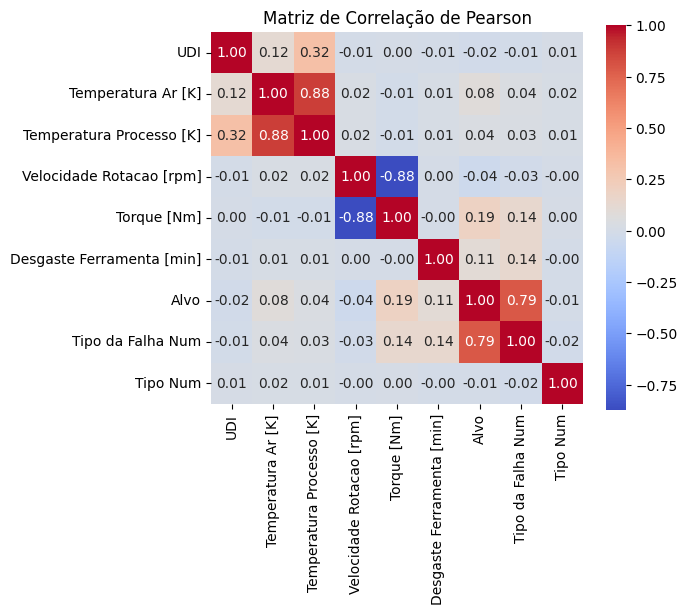

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            cbar=True, square=True)

plt.title("Matriz de Correlação de Pearson")
plt.show()



In [14]:
# Separação dos dados para treino e teste

x = df[['Tipo Num',
        'Temperatura Ar [K]',
        'Temperatura Processo [K]',
        'Velocidade Rotacao [rpm]',
        'Torque [Nm]']]

y = df[['Tipo da Falha']]


In [15]:
# Separação dos dados para treino e teste

from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

In [21]:
# Preparação dos parâmetros do modelo - rede neural MLP

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(20, 30), max_iter=300, activation='relu', random_state=42, verbose=True)

In [22]:
# Treinar o modelo utilizando os dados de treino

treino = mlp.fit(X_treino, y_treino)
treino

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1124: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Iteration 1, loss = 1.79299991
Iteration 2, loss = 0.85315603
Iteration 3, loss = 0.71781476
Iteration 4, loss = 0.44720708
Iteration 5, loss = 0.40037389
Iteration 6, loss = 0.36480982
Iteration 7, loss = 0.30769850
Iteration 8, loss = 0.30408900
Iteration 9, loss = 0.30716812
Iteration 10, loss = 0.30194362
Iteration 11, loss = 0.27179646
Iteration 12, loss = 0.23218703
Iteration 13, loss = 0.25247620
Iteration 14, loss = 0.28259163
Iteration 15, loss = 0.22602720
Iteration 16, loss = 0.26215088
Iteration 17, loss = 0.25817250
Iteration 18, loss = 0.22394247
Iteration 19, loss = 0.35882441
Iteration 20, loss = 0.93817879
Iteration 21, loss = 1.10264339
Iteration 22, loss = 0.65614877
Iteration 23, loss = 0.46073642
Iteration 24, loss = 0.30225250
Iteration 25, loss = 0.21349795
Iteration 26, loss = 0.24676567
Iteration 27, loss = 0.22163819
Iteration 28, loss = 0.18123035
Iteration 29, loss = 0.19793361
Iteration 30, loss = 0.19117025
Iteration 31, loss = 0.18989060
Iteration 32, los

MLPClassifier(hidden_layer_sizes=(20, 30), max_iter=300, random_state=42,
              verbose=True)

In [23]:
# Avaliação do modelo nos dados de treino e teste

from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = mlp.predict(X_teste)
acuracia = accuracy_score(y_teste, y_pred)
matriz_confusao = confusion_matrix(y_teste, y_pred)
print(acuracia)


0.9676666666666667


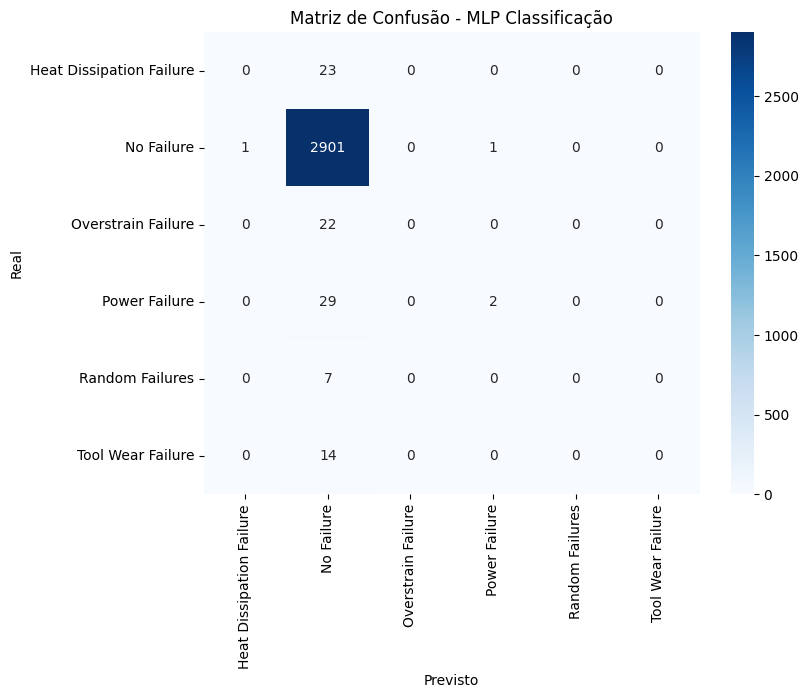

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_treino),
            yticklabels=np.unique(y_treino))
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - MLP Classificação")
plt.show()


In [25]:
# Teste do modelo para uma amostra
# OBSERVAÇÃO: MODELO ERROU AO FAZER A PREVISÃO - Tool Wear Failure
# O que aconteceu com o modelo? Pq não fez a previsão correta?

amostra = np.array([[1, 298.8, 308.9, 1455, 41.3]])

# 4. Fazer previsão
previsao = treino.predict(amostra)
previsao

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


array(['No Failure'], dtype='<U24')

Mostre como melhorar a acurária do modelo?

Mudar parâmetros da rede neural MLP:

a) hidden_layer_sizes=(10), max_iter=100
b) hidden_layer_sizes=(20), max_iter=100
c) hidden_layer_sizes=(50), max_iter=100
d) hidden_layer_sizes=(100), max_iter=100

Incluindo duas camadas ocultas

e) hidden_layer_sizes=(10, 10), max_iter=100
f) hidden_layer_sizes=(50, 50), max_iter=100
g) hidden_layer_sizes=(10, 10, 10), max_iter=100

Utilizando 80% dos dados para treino e 20% para teste